In [1]:
import pandas as pd
import numpy as np

import math

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import src.data.dataprep as prep

In [2]:
nl_data_list = []

for i in range(27):
    # Import the base data and resample it from 5 minutes to hourly
    nl_data = prep.dutch_data('../data/Dutchdata_clean/building_' + str(i) + '.parquet', 'h')
    # Include net load for cost calculations
    nl_data['net_load'] = nl_data['load'] - nl_data['solar_energy']
    # Import a price profile and merge it with the consumption data
    nl_price_data = pd.read_csv('../data/NL_DA_Prices.csv', index_col='Date',parse_dates=True, dayfirst=True)
    nl_data = nl_data.merge(nl_price_data[['offtake', 'injection']], left_index=True, right_index=True)
    # calculate the cost to be a positive net load x offtake minus a negative net load x injection
    nl_data['cost'] = nl_data.apply(lambda row: row['net_load'] * row['injection'] if row['net_load'] < 0 else row['net_load'] * row['offtake'], axis=1)
    
    nl_data_list.append(nl_data)

In [8]:
costs = []

for i in range(len(nl_data_list)):
    costs.append(sum(nl_data_list[i][-10800:]['cost']))

In [11]:
nl_data_list[i][-10800:]

,load,solar_energy,net_load,offtake,injection,cost
2020-05-08 00:00:00,0.648,0.00,0.648,0.17100,0.011,0.110808
2020-05-08 01:00:00,0.175,0.00,0.175,0.16700,0.008,0.029225
2020-05-08 02:00:00,0.170,0.00,0.170,0.16300,0.005,0.027710
2020-05-08 03:00:00,0.169,0.00,0.169,0.16300,0.005,0.027547
2020-05-08 04:00:00,0.170,0.00,0.170,0.16300,0.005,0.027710
...,...,...,...,...,...,...
2021-07-31 19:00:00,0.321,2.15,-1.829,0.22828,0.054,-0.098766
2021-07-31 20:00:00,0.179,1.12,-0.941,0.24328,0.065,-0.061165
2021-07-31 21:00:00,0.200,0.03,0.170,0.22428,0.051,0.038128
2021-07-31 22:00:00,0.199,0.00,0.199,0.27328,0.087,0.054383


In [10]:
np.average(np.array(costs))

458.3256626175434

In [3]:
solar_energy = []
load = []
for i in range(len(nl_data_list)):
    solar_energy.append(nl_data_list[i]['solar_energy'].max())
    load.append(math.floor(nl_data_list[i]['load'].resample('D').sum().max()))
    
solar_energy = np.array(solar_energy)
load = np.array(load)

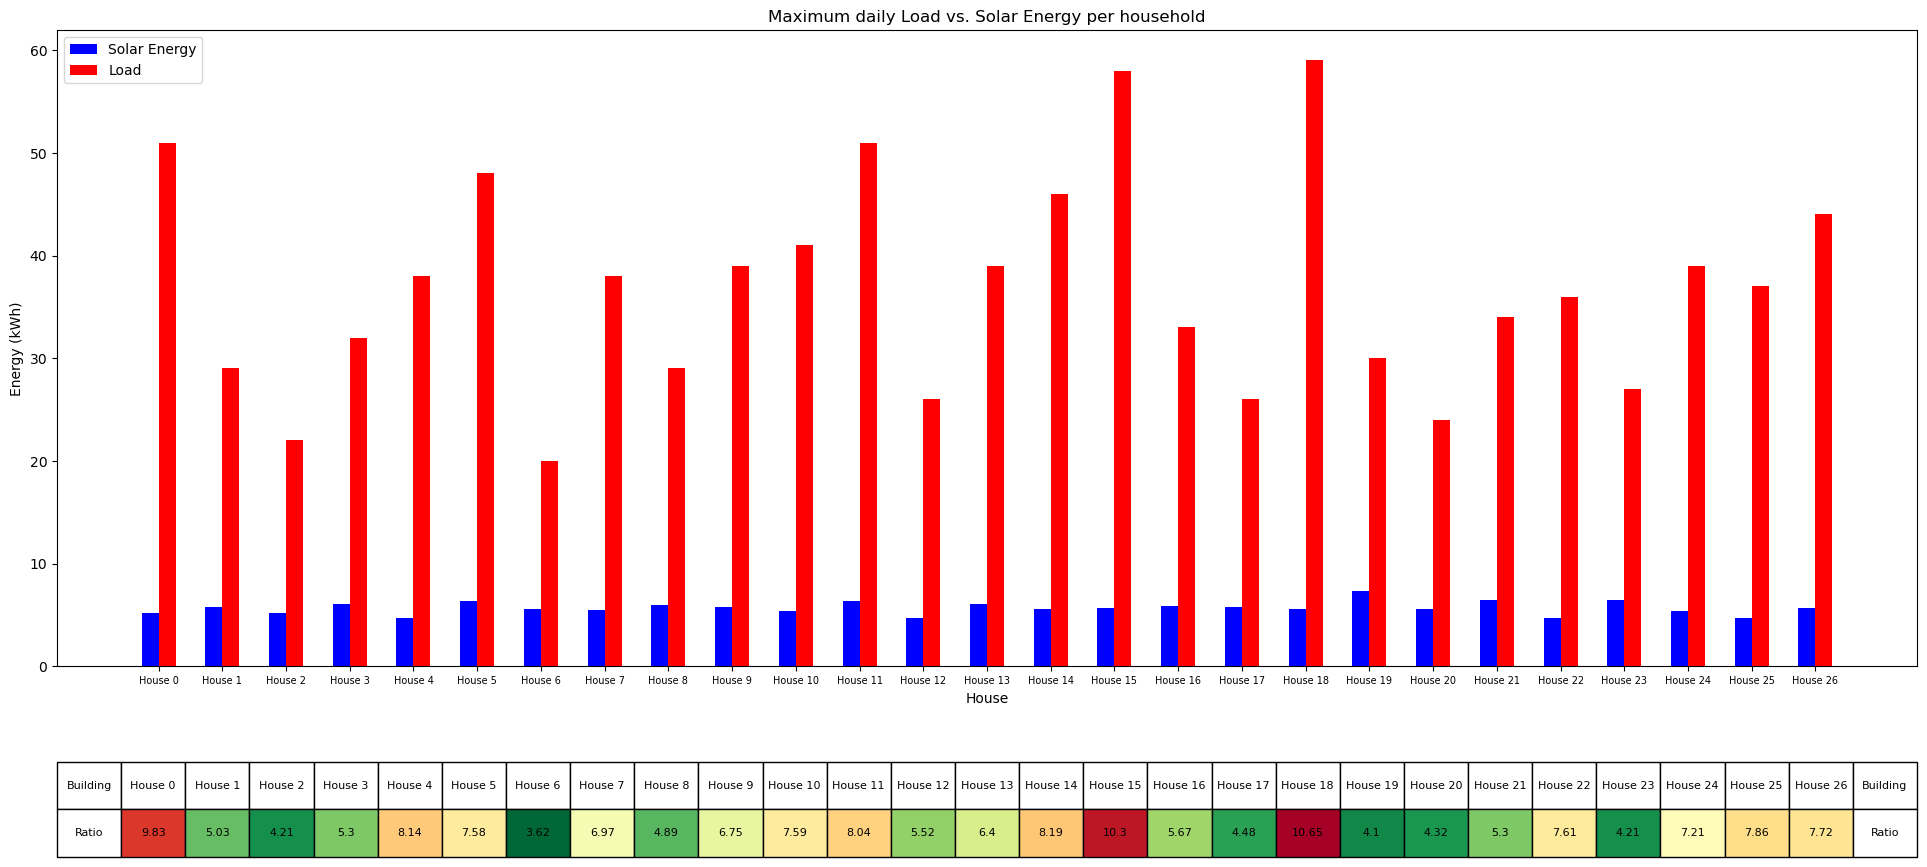

In [4]:
# Compute ratio (handling division by zero)
ratio = np.round(load / solar_energy, 2)

# X locations for the **clusters** (NOT individual bars)
x = np.arange(len(solar_energy)) * 1.5  
width = 0.4  

# Create figure and axis
fig, ax1 = plt.subplots(figsize=(24, 12))

# Plot single bar chart with proper x-alignment
bars1 = ax1.bar(x - width/2, solar_energy, width, color='b', label='Solar Energy')
bars2 = ax1.bar(x + width/2, load, width, color='r', label='Load')

# Labels and title
ax1.set_xlabel("House")
ax1.set_ylabel("Energy (kWh)")
plt.title("Maximum daily Load vs. Solar Energy per household")

# Set x-ticks to align with clusters
ax1.set_xticks(x)
ax1.set_xticklabels([f"House {i}" for i in range(len(ratio))], fontsize=7)

# Legend
ax1.legend(loc="upper left")

# Color scale (Red → Green)
norm = plt.Normalize(vmin=np.min(ratio), vmax=np.max(ratio))
cmap = plt.get_cmap("RdYlGn_r")  # Reverse RdYlGn to have red as highest, green as lowest
colors = [mcolors.to_hex(cmap(norm(value))) for value in ratio]

# Create a table with row names + ratios
table_data = [
    ["Building"] + [f"House {i}" for i in range(len(ratio))] + ["Building"],  # Column headers
    ["Ratio"] + list(ratio.astype(str)) +["Ratio"] # Data row
]

# Create the table
table = ax1.table(cellText=table_data,
                  cellLoc='center',
                  loc='bottom',
                  bbox=[0, -0.3, 1, 0.15])  # Adjust position & size

# Apply colors to the ratio values (skipping the first column)
for i in range(1, len(ratio) + 1):  
    table._cells[(1, i)].set_facecolor(colors[i - 1])

# Adjust layout to fit the table
plt.subplots_adjust(bottom=0.35)

# Show plot
plt.show()

Do some more analyses with averages over the year etc.. Check some yearly ratios as well